# E-Commerce KNN: Visualisierungen (Modern Edition)

In diesem Notebook zeigen wir, wie man die Ergebnisse eines KNNs visuell aufbereitet, um sie z.B. dem Management oder in Prüfungen optimal zu präsentieren.
Wir nutzen hierfür ein modernes Corporate Design mit hohem Kontrast.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# --- 🎨 MODERNES STYLING SETUP ---
C_DARKBLUE = '#20344f'
C_BLUEGREY = '#52627b'
C_LIGHTGREY = '#edeef0'
C_LEMON = '#e0ff01'

mpl.rcParams['figure.facecolor'] = C_DARKBLUE
mpl.rcParams['axes.facecolor'] = C_DARKBLUE
mpl.rcParams['axes.edgecolor'] = C_BLUEGREY
mpl.rcParams['axes.labelcolor'] = C_LIGHTGREY
mpl.rcParams['xtick.color'] = C_LIGHTGREY
mpl.rcParams['ytick.color'] = C_LIGHTGREY
mpl.rcParams['text.color'] = C_LIGHTGREY
mpl.rcParams['grid.color'] = C_BLUEGREY

# Ein eigener Farbverlauf für Heatmaps (von Dunkelblau über Blaugrau zu Lemon)
cmap_modern = LinearSegmentedColormap.from_list('modern', [C_DARKBLUE, C_BLUEGREY, C_LEMON])
# ---------------------------------

# 1. Daten laden und vorbereiten
df = pd.read_csv("online_shoppers_intention.csv")
df_encoded = pd.get_dummies(df, columns=['Month', 'VisitorType', 'Weekend'], drop_first=True)

X = df_encoded.drop(columns=['Revenue'])
y = df_encoded['Revenue'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. KNN Trainieren
print("Trainiere das KNN... Bitte warten.")
mlp = MLPClassifier(hidden_layer_sizes=(32, 16), activation='relu', max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)
print("Training abgeschlossen!")

Trainiere das KNN... Bitte warten.
Training abgeschlossen!


### 1. Die Lernkurve (Loss Curve)
Zeigt, wie der Fehler der KI über die Epochen hinweg sinkt.

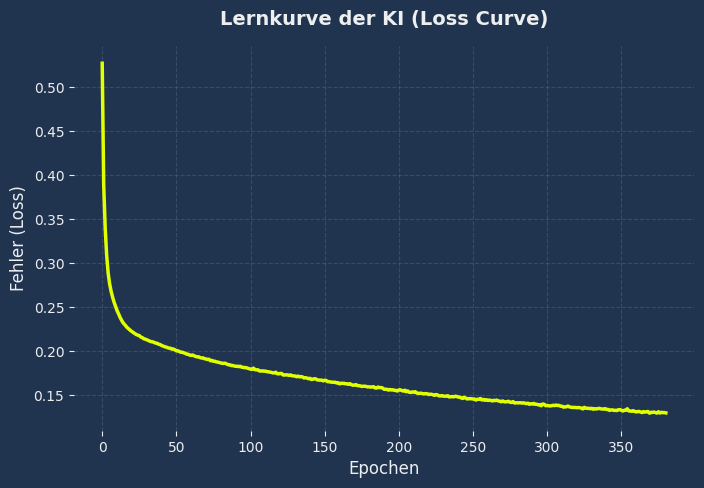

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, color=C_LEMON, linewidth=2.5)
plt.title("Lernkurve der KI (Loss Curve)", fontsize=14, fontweight='bold', color=C_LIGHTGREY, pad=15)
plt.xlabel("Epochen", fontsize=12)
plt.ylabel("Fehler (Loss)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Rand entfernen für moderneren Look
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.show()

### 2. Confusion Matrix Heatmap
Eine farbliche Darstellung der wahren vs. falschen Vorhersagen.

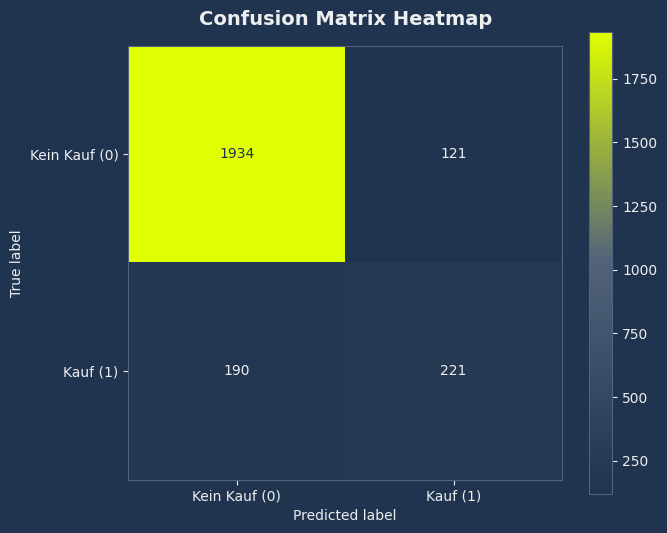

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay.from_estimator(
    mlp, X_test_scaled, y_test, 
    display_labels=['Kein Kauf (0)', 'Kauf (1)'], 
    cmap=cmap_modern, ax=ax
)
plt.title("Confusion Matrix Heatmap", fontsize=14, fontweight='bold', pad=15)

# Passe die Textfarbe in der Matrix an, damit sie auf hell/dunkel lesbar bleibt
for text in disp.text_.ravel():
    text.set_color(C_DARKBLUE if float(text.get_text()) > 300 else C_LIGHTGREY)

plt.show()

### 3. ROC Kurve
Wichtig für Prüfungen: Zeigt das Verhältnis zwischen True Positive Rate und False Positive Rate.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


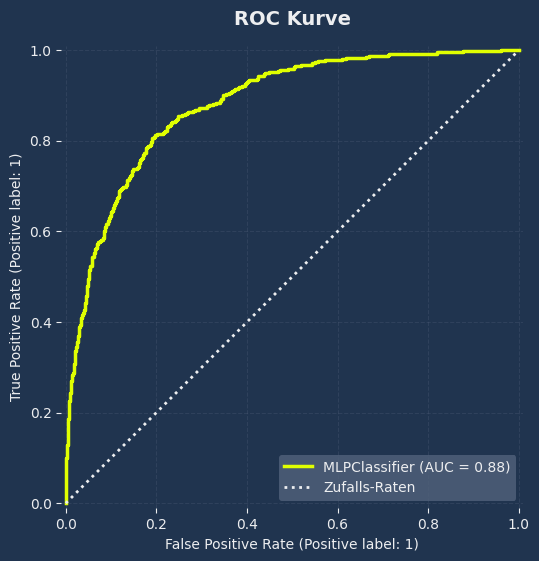

In [9]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(mlp, X_test_scaled, y_test, ax=ax, color=C_LEMON, linewidth=2.5)
plt.plot([0, 1], [0, 1], color=C_LIGHTGREY, linestyle=':', linewidth=2, label='Zufalls-Raten')

plt.title("ROC Kurve", fontsize=14, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(facecolor=C_BLUEGREY, edgecolor='none', labelcolor=C_LIGHTGREY)

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.show()

### 4. Permutation Feature Importance
Welche Daten haben die Entscheidung der KI am meisten beeinflusst?

Berechne Wichtigkeiten... (kann kurz dauern)


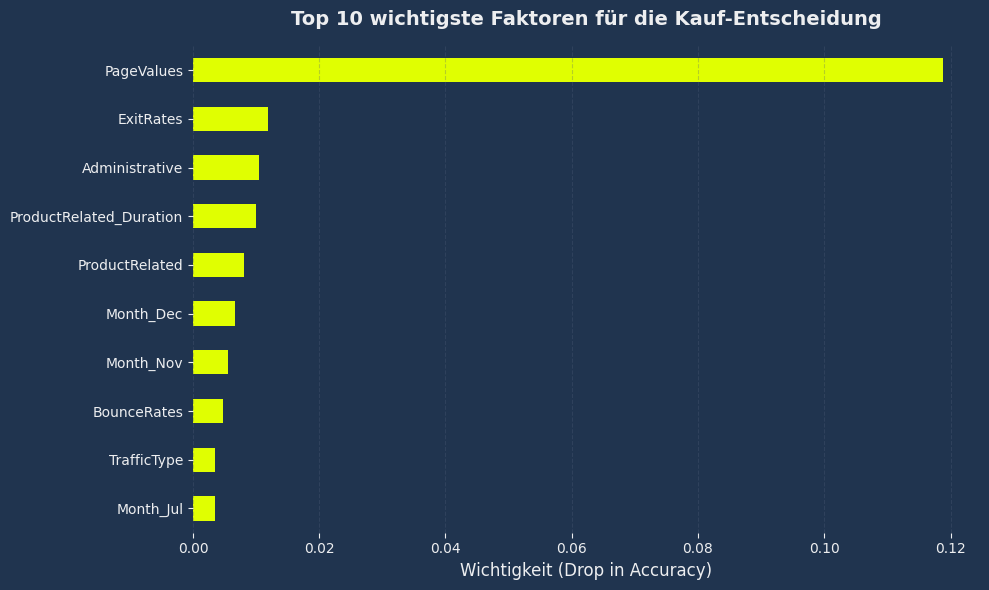

In [10]:
from sklearn.inspection import permutation_importance

print("Berechne Wichtigkeiten... (kann kurz dauern)")
ergebnis = permutation_importance(mlp, X_test_scaled, y_test, n_repeats=5, random_state=42, n_jobs=-1)

# Wir nehmen nur die Top 10 wichtigsten Features für eine saubere Grafik
wichtigkeiten = pd.Series(ergebnis.importances_mean, index=X.columns)
top_10 = wichtigkeiten.sort_values().tail(10)

plt.figure(figsize=(10, 6))
bars = top_10.plot(kind='barh', color=C_LEMON)
plt.title("Top 10 wichtigste Faktoren für die Kauf-Entscheidung", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Wichtigkeit (Drop in Accuracy)", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()